# 卷积神经网络入门

这个 notebook 的重点是理解 CNN 为什么适合图像任务。和全连接网络相比，卷积利用图像的局部结构，既大幅减少参数量，又保留了空间信息。

## CNN 三大核心思想
- **局部感受野**：每次只看图像的一个小区域，而不是全图全连接。
- **权值共享**：同一个卷积核在整张图上滑动，学会识别"同一种局部模式"。
- **分层提特征**：浅层学边缘和纹理，深层学更复杂的语义组合。

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose
from torch import nn
from torchviz import make_dot
from torch.nn import functional as F
from torch.optim import Adam, SGD
from tqdm import tqdm
from matplotlib import pyplot as plt

import torch
import numpy as np
import pandas as pd
import os

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 先看数据集，再看网络

FashionMNIST 是 10 类灰度服装图像。理解输入长什么样，再去看网络结构会更自然。

关注两点：
- 灰度图 → 通道数为 1（RGB 图像则为 3）。
- 所有图片尺寸一致（28×28），便于批量处理。

In [19]:
# FashionMNIST 常用归一化参数
fashion_mean = 0.2860
fashion_std = 0.3530
img_transform = Compose([
    ToTensor(),
    Normalize((fashion_mean,), (fashion_std,))
])

train_ds = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=img_transform
)

test_ds = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=img_transform
)

# 将训练集划分为训练集和验证集
train_ds, val_ds = random_split(
    train_ds, [55000, 5000], torch.Generator().manual_seed(42))

## 标准化的重要性

图像像素通常分布在 0~255 或 0~1。不同数据集的均值和方差差异可能很大。标准化将输入调整到更利于优化的尺度：

\[
x' = \frac{x - \mu}{\sigma}
\]

效果：梯度更新更稳定，减少不同特征尺度不一致带来的训练波动。

In [20]:
subset = train_ds.dataset.data[train_ds.indices].float() / 255.0
mean = subset.mean()
std = subset.std()

print(f"raw mean: {mean}, raw std: {std}")
print("dataset transform uses mean=0.2860, std=0.3530")

raw mean: 0.28556573390960693, raw std: 0.35272860527038574
dataset transform uses mean=0.2860, std=0.3530


## DataLoader 在训练中的作用

神经网络几乎不会一次把全部数据塞进模型，而是按 batch 训练：

- **省内存**：每次只加载一个 batch。
- **更新更频繁**：不等到看完所有数据才更新参数。
- **随机打乱**：破坏样本顺序，帮助优化。

这一段虽然看起来只是"装载数据"，实际上是在搭建训练循环的输入管道。

In [21]:
batch_size = 512
num_workers = 6

train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)



## 卷积层、池化层、全连接层的分工

| 层类型 | 作用 | 对形状的影响 |
|--------|------|-------------|
| 卷积层 | 提取局部模式（边缘、纹理、角点） | 通道数变化，空间尺寸可控制 |
| 池化层 | 压缩空间尺寸，保留主要特征 | 宽高减半（stride=2） |
| 全连接层 | 将高层特征映射到类别分数 | 展平后压缩到类别数 |

建议沿着"输入形状怎么变"这条线理解每一层，而不是只记 API。

In [22]:
class CNN(nn.Module):
    def __init__(self, activation=F.relu):
        super().__init__()
        self.activation = activation

        # 参数说明：
        # in_channels：输入通道数，灰度图像为1，彩色图像为3
        # out_channels：输出通道数，即卷积核的数量
        # kernel_size：卷积核的大小，可以是单个整数（表示宽高相同）或一个元组（表示宽和高）
        # stride：卷积的步幅，默认为1
        # padding：卷积的填充，默认为0，可以是单个整数（表示宽高相同）或一个元组（表示宽和高）

        # 卷积层的设计原则：
        # 1. 卷积层的输出通道数通常是输入通道数的倍数，常见的倍数有2、4、8等，这样可以逐渐增加特征图的数量，提取更多的特征。
        # 2. 卷积核的大小通常选择3x3或5x3，这样可以捕捉局部特征，同时保持计算效率。
        # 3. 卷积层之间可以添加池化层来减少特征图的尺寸，降低计算复杂度，同时增加感受野。

        # 池化层：使用最大池化，池化核大小为2，步幅为2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1. 卷积层1：输入通道数为1，输出通道数为32，卷积核大小为3，步幅为1，填充为1
        # (batch_size, 1, 28, 28) -> (batch_size, 32, 28, 28)
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=32, kernel_size=3, padding=1)

        # 2. 卷积层2：输入通道数为32，输出通道数为32，卷积核大小为3, 填充为1
        # (batch_size, 32, 28, 28) -> (batch_size, 32, 14, 14)
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=32, kernel_size=3, padding=1)

        # 3. 卷积层3：输入通道数为32，输出通道数为64，卷积核大小为3, 填充为1
        # (batch_size, 32, 14, 14) -> (batch_size, 64, 7, 7)
        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # 4. 卷积层4：输入通道数为64，输出通道数为64，卷积核大小为3, 填充为1
        # (batch_size, 64, 7, 7) -> (batch_size, 64, 3, 3)
        self.conv4 = nn.Conv2d(
            in_channels=64, out_channels=64, kernel_size=3, padding=1)

        # 5. 卷积层5：输入通道数为64，输出通道数为128，卷积核大小为3, 填充为1
        # (batch_size, 64, 3, 3) -> (batch_size, 128, 3, 3)
        self.conv5 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # 6. 卷积层6：输入通道数为128，输出通道数为128，卷积核大小为3, 填充为1
        # (batch_size, 128, 3, 3) -> (batch_size, 128, 3, 3)
        self.conv6 = nn.Conv2d(
            in_channels=128, out_channels=128, kernel_size=3, padding=1)

        # 7. 展平层：将卷积层的输出展平为一维向量
        self.flatten = nn.Flatten()
        # 8. 全连接层1：输入特征数为128*3*3，输出特征数为128
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        # 9. 全连接层2：输入特征数为128，输出特征数为10（对应10个类别）
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        act = self.activation
        # 1 * 28 * 28 -> 32 * 14 * 14
        x = self.pool(act(self.conv2(act(self.conv1(x)))))
        # 32 * 14 * 14 -> 64 * 7 * 7
        x = self.pool(act(self.conv4(act(self.conv3(x)))))
        # 64 * 7 * 7 -> 128 * 3 * 3
        x = self.pool(act(self.conv6(act(self.conv5(x)))))

        # 展平之后再进行全连接层的计算
        x = self.flatten(x)
        x = act(self.fc1(x))
        x = self.fc2(x)

        return x


total = 0
for i, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparameter num: {np.prod(value.shape)}")
    total += np.prod(value.shape)
print(f"Total parameters: {total}")

conv1.weight	parameter num: 288
conv1.bias	parameter num: 32
conv2.weight	parameter num: 9216
conv2.bias	parameter num: 32
conv3.weight	parameter num: 18432
conv3.bias	parameter num: 64
conv4.weight	parameter num: 36864
conv4.bias	parameter num: 64
conv5.weight	parameter num: 73728
conv5.bias	parameter num: 128
conv6.weight	parameter num: 147456
conv6.bias	parameter num: 128
fc1.weight	parameter num: 147456
fc1.bias	parameter num: 128
fc2.weight	parameter num: 1280
fc2.bias	parameter num: 10
Total parameters: 435306


In [ ]:
model = CNN().to(device)

img = torch.randn(1, 1, 28, 28).to(device)

output = model(img)

make_dot(output, params=dict(model.named_parameters())).save("dot/model_CNN.dot")

'model_CNN.dot'

In [90]:
@torch.no_grad() 
def evaluate(model, dataloader, loss_fn):
    loss_list = []
    total_correct = 0
    total_count = 0

    for data, label in dataloader:
        data = data.to(device)
        label = label.to(device)

        logits = model(data)
        loss = loss_fn(logits, label)
        loss_list.append(loss.item())

        pred = logits.argmax(dim=1)
        total_correct += (pred == label).sum().item()
        total_count += label.size(0)

    accuracy = total_correct / total_count
    return np.mean(loss_list), accuracy


def train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=500,
    checkpoints_callback=None,
    earlystop_callback=None,
    tensorboard_callback=None
):

    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0
    model.train()

    with tqdm(total=epochs * len(train_loader), desc="Training") as pbar:
        for epoch in range(epochs):
            for data, label in train_loader:
                data = data.to(device)
                label = label.to(device)
                optimizer.zero_grad()

                logits = model(data)
                loss = loss_fn(logits, label)
                loss.backward()
                optimizer.step()

                pred = logits.argmax(dim=1)
                acc = (pred == label).float().mean().item()
                loss = loss.item()

                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss,
                    'accuracy': acc
                })

                if global_step % eval_interval == 0:
                    model.eval()
                    val_loss, val_acc = evaluate(
                        model, val_loader, loss_fn)
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss,
                        'accuracy': val_acc
                    })
                    model.train()

                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                        )
                    if checkpoints_callback is not None:
                        checkpoints_callback(
                            step=global_step,
                            state_dict=model.state_dict(),
                            metric=val_acc
                        )
                    if earlystop_callback is not None and earlystop_callback(val_acc):
                        print(
                            f"Early stop at epoch {epoch} / step {global_step}, val_acc: {val_acc:.4f}")
                        return record_dict

                global_step += 1
                pbar.update(1)
                pbar.set_postfix({'epoch': epoch})

    return record_dict

In [91]:
class EarlyStopper:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0

    def __call__(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

In [76]:
model = CNN(F.relu).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=200,
)

print(
    f"Relu Final test accuracy: {evaluate(model, test_loader, loss_fn)[1]:.4f}")

Training: 100%|██████████| 1080/1080 [06:39<00:00,  2.70it/s, epoch=19]


In [ ]:
model = CNN(F.selu).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

earlystopper = EarlyStopper(patience=10, min_delta=0.001)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=200,
    earlystop_callback=earlystopper
)

print(
    f"Selu Final test accuracy: {evaluate(model, test_loader, loss_fn)[1]:.4f}")

Training: 100%|██████████| 2160/2160 [05:36<00:00,  6.43it/s, epoch=19]


Selu Final test accuracy: 0.9189


In [31]:
from base import TorchTrainer, ReduceLROnPlateau
import sys
from pathlib import Path

# 将项目根目录 c:\Repos\AI 加入导入路径
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


model = CNN(F.selu).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

trainer = TorchTrainer(
    model=model,
    criterion=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
    checkpoint_dir="./checkpoints/cnn_fashionmnist"
)

trainer.fit(train_loader, val_loader, epochs=50)

# trainer.load_checkpoint("./checkpoints/cnn_fashionmnist/best.pt")

test_log = trainer.evaluate(test_loader)
print(f"Final test accuracy: {test_log['acc']:.4f}")

Epoch 1/50 | train_loss=0.5496 | train_acc=0.7975 | train_balanced_acc=0.7974 | train_f1_macro=0.7940 | val_loss=0.4465 | val_acc=0.8398 | val_balanced_acc=0.8402 | val_f1_macro=0.8273 | lr=0.0010 | epoch_seconds=17.5261


Epoch 2/50 | train_loss=0.3205 | train_acc=0.8836 | train_balanced_acc=0.8835 | train_f1_macro=0.8829 | val_loss=0.3088 | val_acc=0.8858 | val_balanced_acc=0.8863 | val_f1_macro=0.8863 | lr=0.0010 | epoch_seconds=19.0212


Epoch 3/50 | train_loss=0.2615 | train_acc=0.9054 | train_balanced_acc=0.9053 | train_f1_macro=0.9050 | val_loss=0.2810 | val_acc=0.8972 | val_balanced_acc=0.8986 | val_f1_macro=0.8972 | lr=0.0010 | epoch_seconds=18.8116


Epoch 4/50 | train_loss=0.2228 | train_acc=0.9188 | train_balanced_acc=0.9188 | train_f1_macro=0.9185 | val_loss=0.2704 | val_acc=0.9028 | val_balanced_acc=0.9043 | val_f1_macro=0.9033 | lr=0.0010 | epoch_seconds=18.2190


Epoch 5/50 | train_loss=0.1954 | train_acc=0.9286 | train_balanced_acc=0.9285 | train_f1_macro=0.9283 | val_loss=0.2373 | val_acc=0.9124 | val_balanced_acc=0.9133 | val_f1_macro=0.9127 | lr=0.0010 | epoch_seconds=17.7296


...

Epoch 9/50 | train_loss=0.1136 | train_acc=0.9574 | train_balanced_acc=0.9573 | train_f1_macro=0.9572 | val_loss=0.2237 | val_acc=0.9280 | val_balanced_acc=0.9287 | val_f1_macro=0.9283 | lr=0.0010 | epoch_seconds=17.7456


Epoch 10/50 | train_loss=0.0940 | train_acc=0.9647 | train_balanced_acc=0.9647 | train_f1_macro=0.9646 | val_loss=0.2583 | val_acc=0.9148 | val_balanced_acc=0.9143 | val_f1_macro=0.9143 | lr=0.0010 | epoch_seconds=17.6248


Epoch 11/50 | train_loss=0.0840 | train_acc=0.9688 | train_balanced_acc=0.9687 | train_f1_macro=0.9687 | val_loss=0.2629 | val_acc=0.9222 | val_balanced_acc=0.9234 | val_f1_macro=0.9226 | lr=0.0005 | epoch_seconds=17.8011


Epoch 12/50 | train_loss=0.0427 | train_acc=0.9852 | train_balanced_acc=0.9851 | train_f1_macro=0.9851 | val_loss=0.2506 | val_acc=0.9292 | val_balanced_acc=0.9301 | val_f1_macro=0.9299 | lr=0.0005 | epoch_seconds=17.7779
早停触发：val_loss 连续 5 轮没有改善，最佳 epoch = 7


Final test accuracy: 0.9256


## 深度可分离卷积

将标准卷积拆成两步：
1. **深度卷积**（Depthwise）：每个输入通道独立做卷积，不混合通道。
2. **逐点卷积**（Pointwise）：用 1×1 卷积将深度卷积的输出做通道混合。

**优势**：参数量和计算量显著降低。计算量比例约为 $(\frac{1}{N} + \frac{1}{D_K^2})（N 为输出通道数，(D_K) 为卷积核尺寸）$

**特点**：深度可分离卷积将标准卷积分解为深度卷积（逐通道独立卷积）和逐点卷积（1×1 通道混合），大幅减少参数量和计算量。

## 感受野与卷积核尺寸

**感受野**：卷积层能"看到"的输入区域大小。堆叠卷积层会逐步扩大感受野。例如两层 3×3 卷积的感受野等价于一层 5×5 卷积，但参数量更少。

**为什么卷积核常用奇数尺寸**（3×3, 5×5）：
- 奇数卷积核有明确的中心像素，便于对齐和保持空间对称。
- 偶数卷积核没有中心，可能导致特征图偏移。

In [94]:
class DepthWiseConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super().__init__()

        # groups参数指定了卷积操作的分组数，当groups等于输入通道数时
        # 每个输入通道都会被独立地卷积，这就是深度卷积的实现方式。
        self.depthwise = nn.Conv2d(
            in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size,
            stride=stride, padding=padding, groups=in_channels, bias=False
        )

        # 逐点卷积使用1x1卷积核，将深度卷积的输出进行线性组合，改变通道数
        self.pointwise = nn.Conv2d(
            in_channels=in_channels, out_channels=out_channels, kernel_size=1, bias=bias
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

In [100]:
class CNN(nn.Module):
    def __init__(self, activation=F.relu):
        super().__init__()
        self.activation = activation

        # 池化层：使用最大池化，池化核大小为2，步幅为2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=32, kernel_size=3, padding="same")
        self.conv2 = DepthWiseConv2d(
            in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.conv3 = DepthWiseConv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.conv4 = DepthWiseConv2d(
            in_channels=64, out_channels=64, kernel_size=3, padding="same")
        self.conv5 = DepthWiseConv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding="same")
        self.conv6 = DepthWiseConv2d(
            in_channels=128, out_channels=128, kernel_size=3, padding="same")

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        act = self.activation
        x = self.pool(act(self.conv2(act(self.conv1(x)))))
        x = self.pool(act(self.conv4(act(self.conv3(x)))))
        x = self.pool(act(self.conv6(act(self.conv5(x)))))

        x = self.flatten(x)
        x = act(self.fc1(x))
        x = self.fc2(x)

        return x


for i, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparameter num: {value.numel()}")
print(f"Total parameters: {sum(p.numel() for p in CNN().parameters())}")

conv1.weight	parameter num: 288
conv1.bias	parameter num: 32
conv2.depthwise.weight	parameter num: 288
conv2.pointwise.weight	parameter num: 1024
conv2.pointwise.bias	parameter num: 32
conv3.depthwise.weight	parameter num: 288
conv3.pointwise.weight	parameter num: 2048
conv3.pointwise.bias	parameter num: 64
conv4.depthwise.weight	parameter num: 576
conv4.pointwise.weight	parameter num: 4096
conv4.pointwise.bias	parameter num: 64
conv5.depthwise.weight	parameter num: 576
conv5.pointwise.weight	parameter num: 8192
conv5.pointwise.bias	parameter num: 128
conv6.depthwise.weight	parameter num: 1152
conv6.pointwise.weight	parameter num: 16384
conv6.pointwise.bias	parameter num: 128
fc1.weight	parameter num: 147456
fc1.bias	parameter num: 128
fc2.weight	parameter num: 1280
fc2.bias	parameter num: 10
Total parameters: 184234


In [104]:
model = CNN(F.selu).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

earlystopper = EarlyStopper(patience=5, min_delta=0.001)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=200,
    earlystop_callback=earlystopper
)

Training: 100%|██████████| 2160/2160 [05:19<00:00,  6.76it/s, epoch=19]


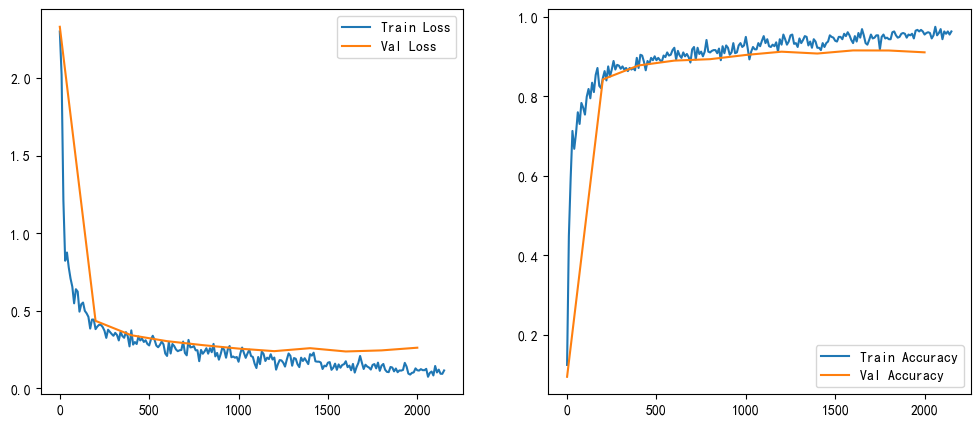

loss: 0.2826
accuracy: 0.9126


In [112]:
plt_interval = 10
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([x['step'] for x in record_dict['train'][::plt_interval]], [x['loss']
         for x in record_dict['train'][::plt_interval]], label='Train Loss')
plt.plot([x['step'] for x in record_dict['val']], [x['loss']
         for x in record_dict['val']], label='Val Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot([x['step'] for x in record_dict['train'][::plt_interval]], [x['accuracy']
         for x in record_dict['train'][::plt_interval]], label='Train Accuracy')
plt.plot([x['step'] for x in record_dict['val']], [x['accuracy']
         for x in record_dict['val']], label='Val Accuracy')
plt.legend()
plt.show()

model.eval()
loss, acc = evaluate(model, test_loader, loss_fn)
print(f"loss: {loss:.4f}\naccuracy: {acc:.4f}")

In [ ]:
# 计算量优化比例
# M，N，DF，DK M为输入通道数，N为输出通道数，DF为特征图的空间尺寸，DK为卷积核的空间尺寸
# DK * DK * M * DF * DF + M * N * DF * DF 为深度可分离卷积的计算量
# DK * DK * M * N * DF * DF 为标准卷积的计算量
# (DK * DK * M * DF * DF + M * N * DF * DF) / (DK * DK * M * N * DF * DF) = 1/N + 1/(DK*DK)